In [2]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

"""path0315 = Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_cargo_radius0.315')
path059 = Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_cargo_radius0.59')
path36 = Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_kMT0.0904_kcargo0.0226_radius3.6')
path50 = Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_kMT0.0904_kcargo0.0226_radius5.0')
"""

path05 =Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_kMT0.0904_kcargo0.0226_radius0.5')
path50 =Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_kMT0.0904_kcargo0.0226_radius5.0')

datas = []
rs = [0.5, 5.0]

for path in [path05, path50]:
    zarr_path = path / 'cargo_msd_seeds.zarr'
    data = zarr.open_array(zarr_path, mode='r')
    datas.append(data)

plt.style.use('../../my_style.mplstyle')

'\nfig.savefig(cd/"figure/MSD.png", bbox_inches=\'tight\')\nfig.savefig(cd/"figure/MSD.pdf", bbox_inches=\'tight\')\n'

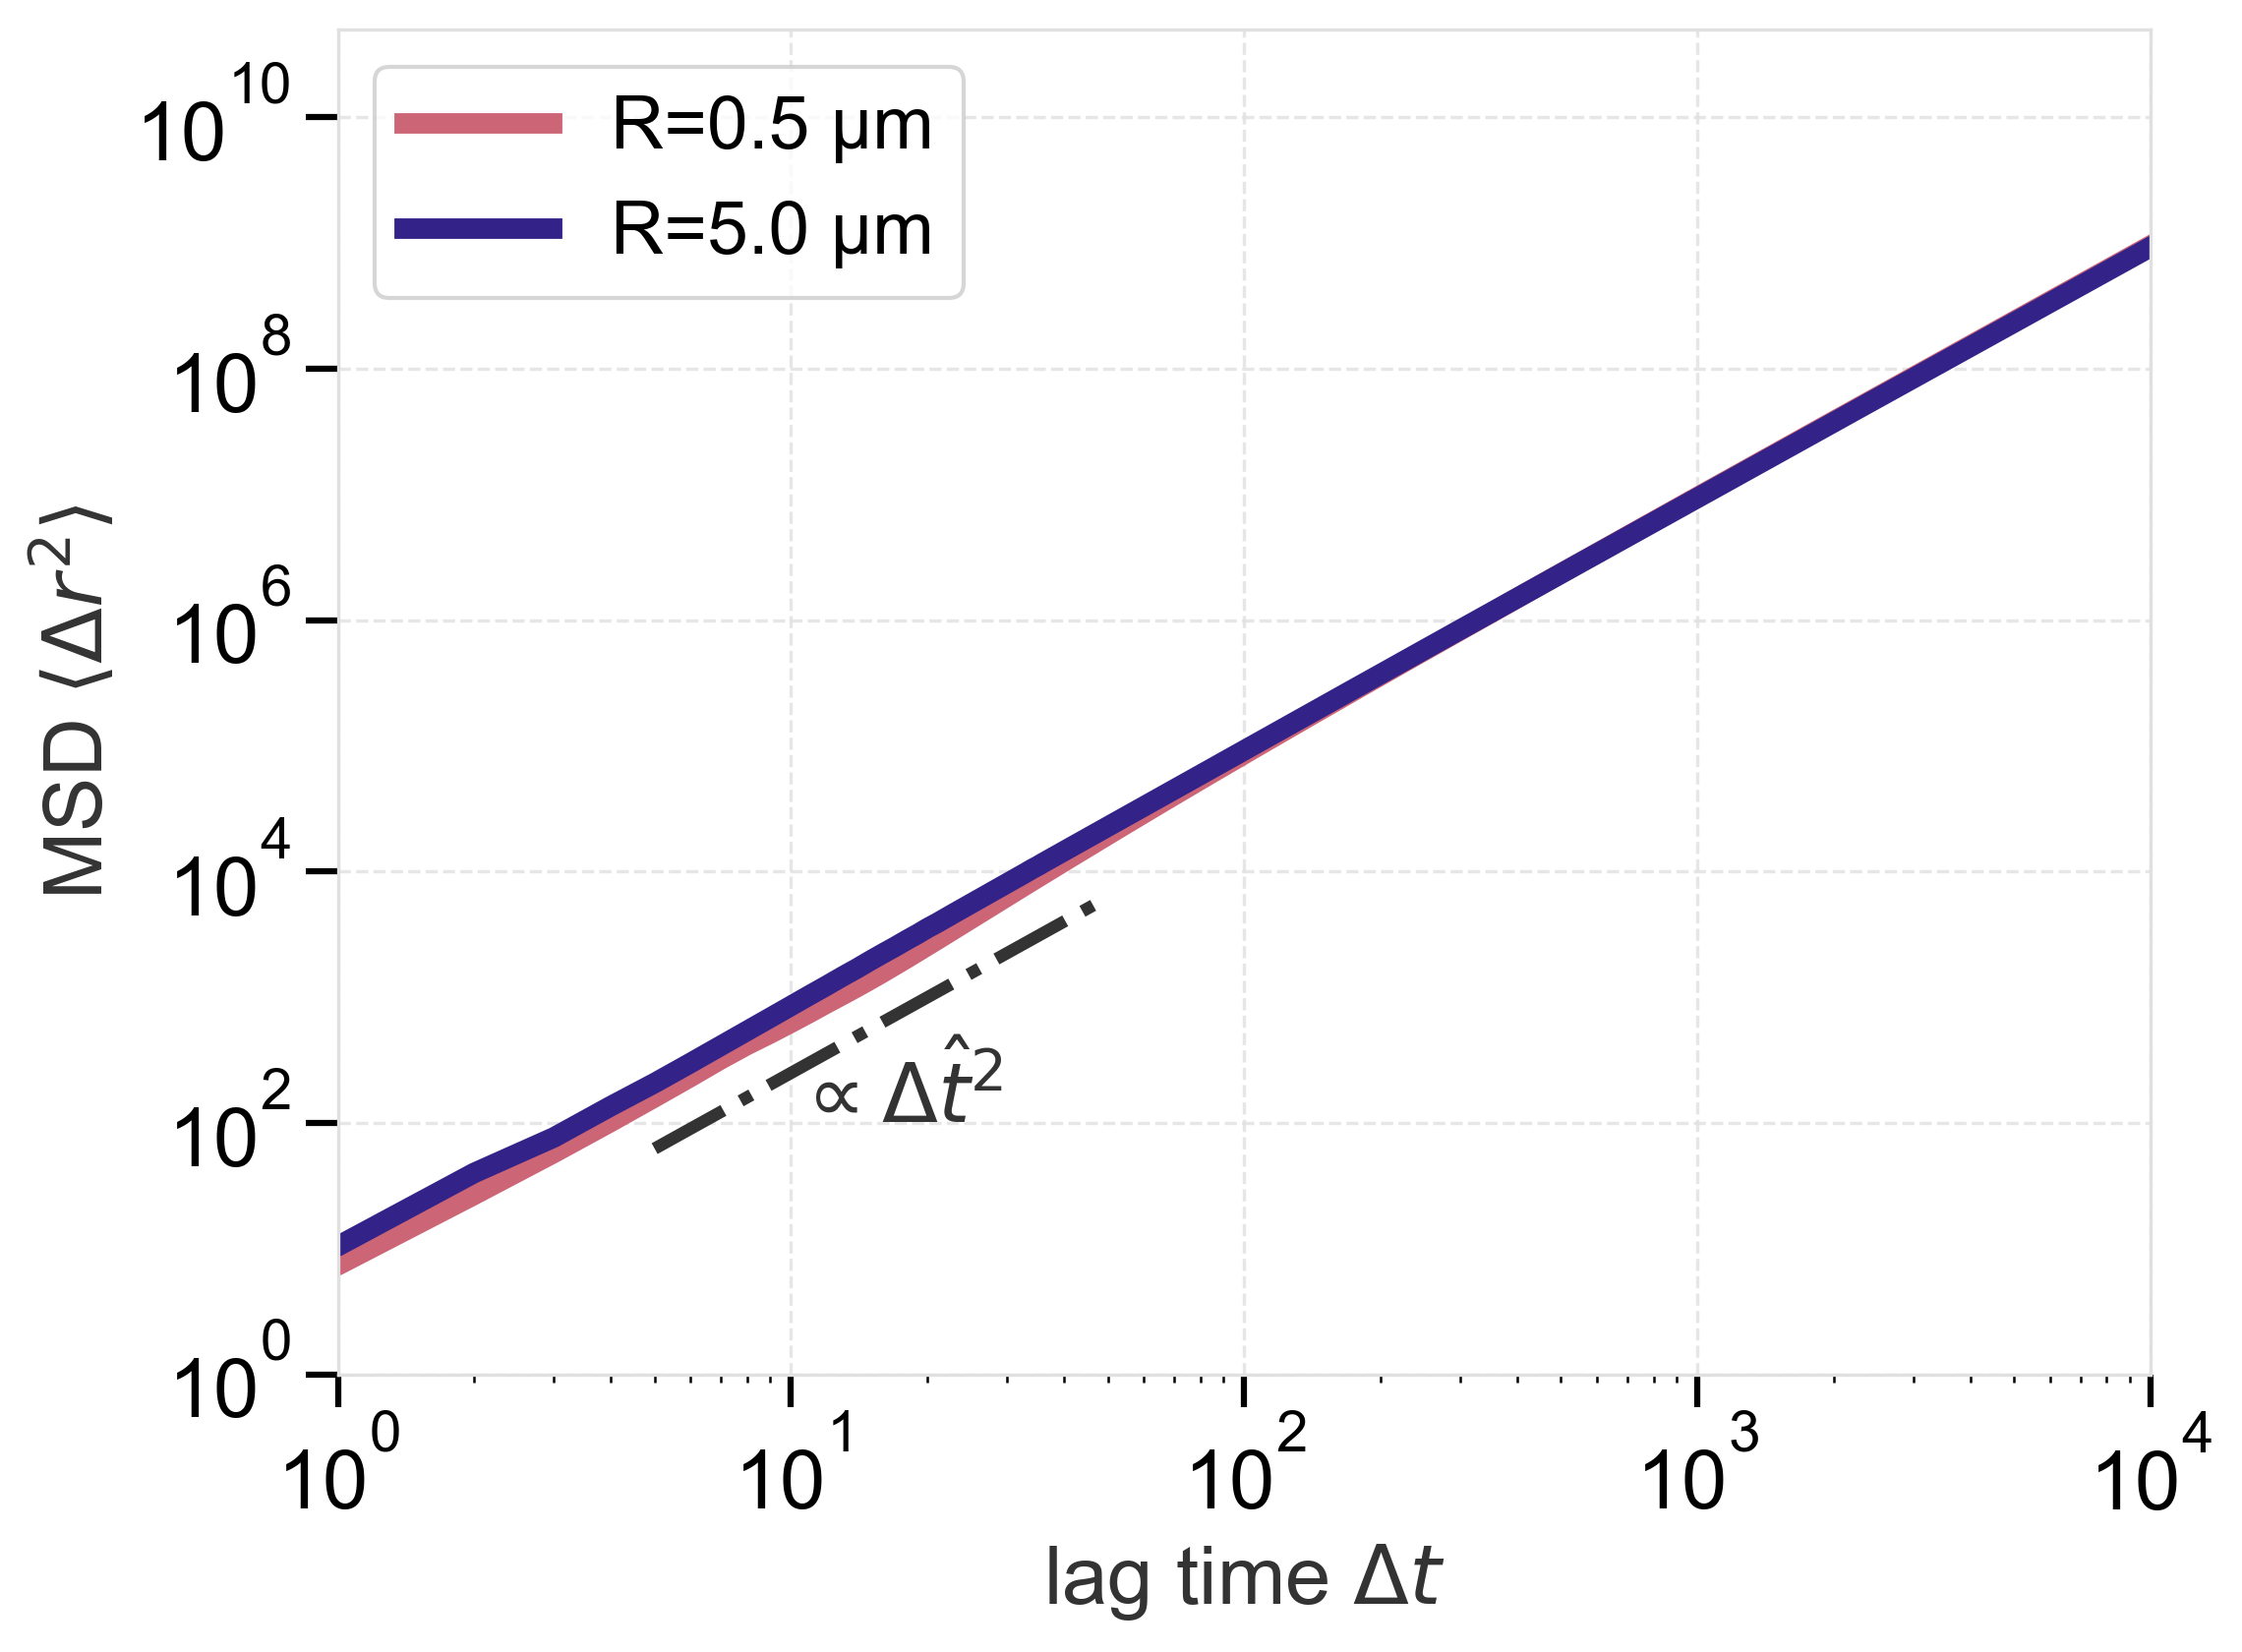

In [3]:
length = datas[0].shape[1]

tau = 5*1e-2
dMT = 25 * 1e-3

t = np.arange(length)

fig, ax = plt.subplots()

"""
for i in range(data.shape[0]):
    ax.plot(t, data[i, :], alpha=0.01, color="#333333")
"""
for i in range(len(datas)):
    ax.plot(t, np.mean(datas[i], axis=0)*dMT, label=f"R={rs[i]} \u03bcm", lw=5)

t1 = np.arange(1e3, 1e4)*tau
t2 = np.arange(1e2, 1e3)*tau

y1 = 1.0e1 * t1 ** 1.0 * dMT
y2 = 1.0e2 * t2 ** 2.0 * dMT

#ax.plot(t1, y1, c = '#333333', linestyle = '--')
ax.plot(t2, y2, c = '#333333', linestyle = '-.')

#ax.text(2e3, 7e3, r'$\propto \Delta \hat{t}^{1}$', color='#333333')
ax.text(1e1, 1e2, r'$\propto \Delta \hat{t}^{2}$', color='#333333')

ax.legend()

ax.set(
    xlim=(1e-0, 1e4),
    ylim=(1e-0, 5*1e10),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta t$',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$'
    )


cd=Path.cwd()
"""
fig.savefig(cd/"figure/MSD.png", bbox_inches='tight')
fig.savefig(cd/"figure/MSD.pdf", bbox_inches='tight')
"""

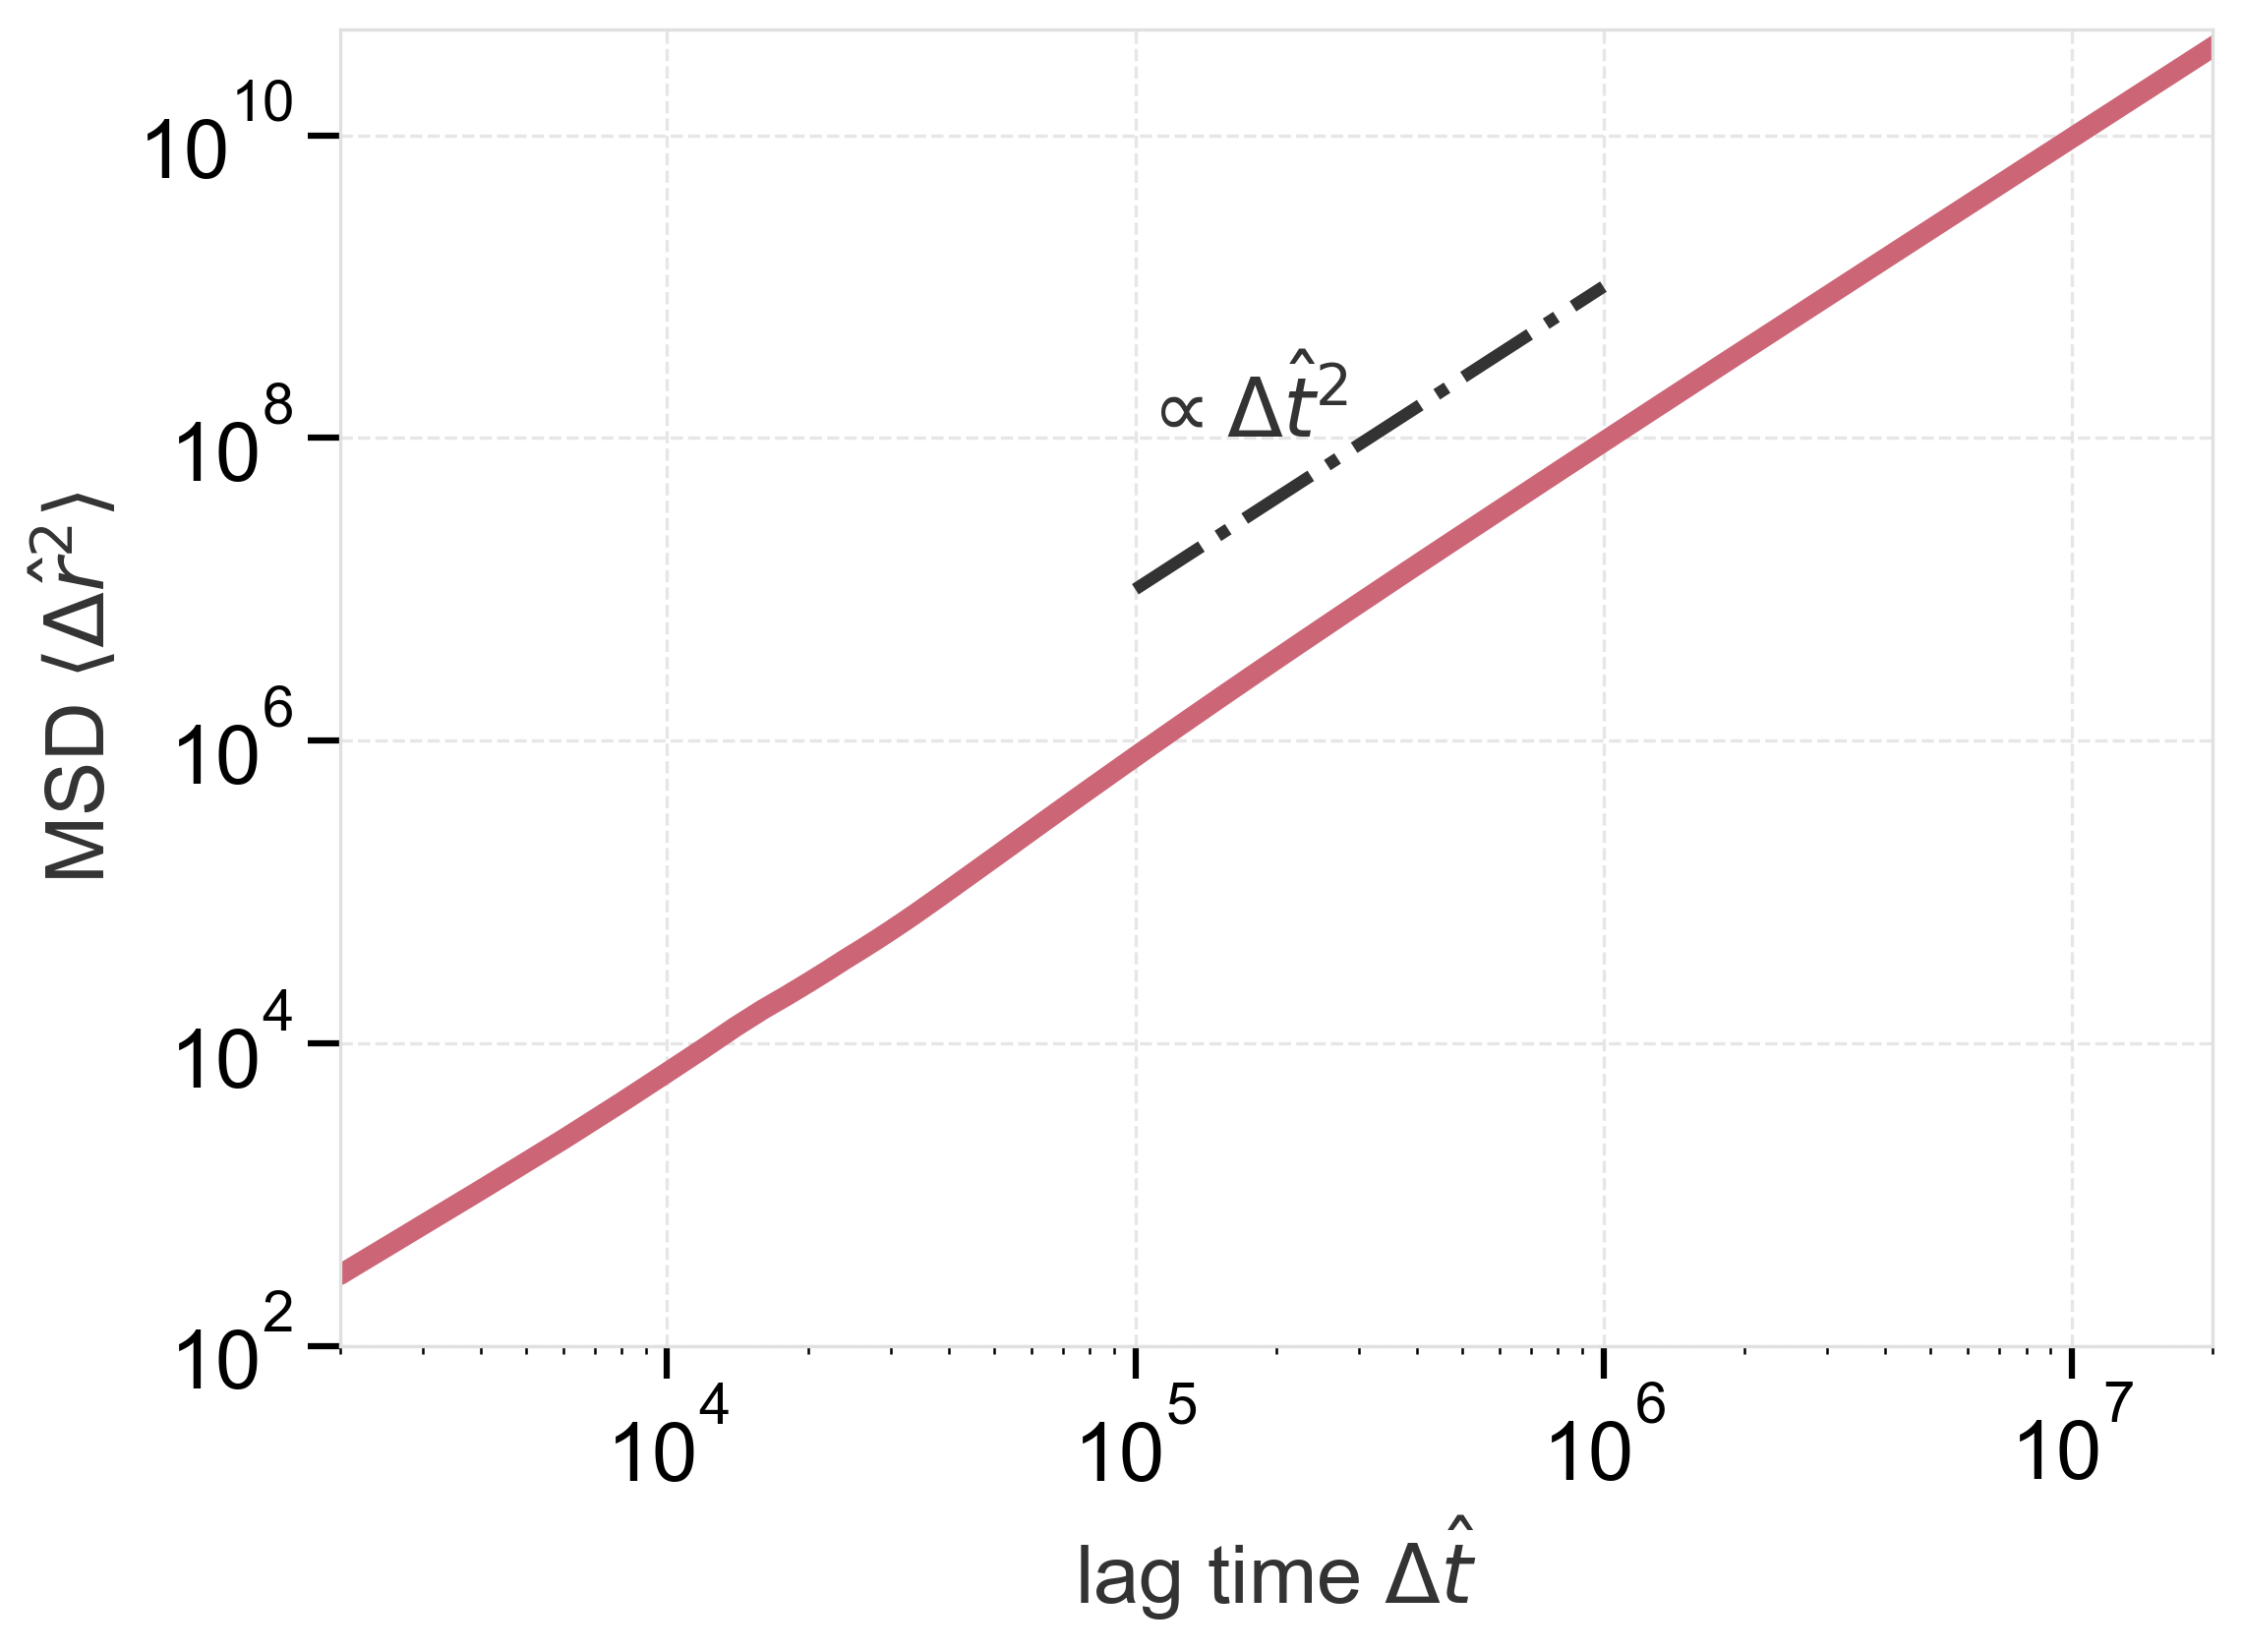

In [6]:
length = datas[0].shape[1]

tau = 5*1e-2
dMT = 25 * 1e-3

t = np.arange(length) * 2000

fig, ax = plt.subplots()

"""
for i in range(data.shape[0]):
    ax.plot(t, data[i, :], alpha=0.01, color="#333333")
"""
for i in range(1):
    ax.plot(t, np.mean(datas[i], axis=0), label=f"R={rs[i]} \u03bcm", lw=5)

t1 = np.arange(1e3, 1e4)
t2 = np.arange(1e5, 1e6)

y1 = 1.0e1 * t1 ** 1.0
y2 = 1.0e-3 * t2 ** 2.0

#ax.plot(t1, y1, c = '#333333', linestyle = '--')
ax.plot(t2, y2, c = '#333333', linestyle = '-.')

#ax.text(2e3, 7e3, r'$\propto \Delta \hat{t}^{1}$', color='#333333')
ax.text(1e5, 1e8, r'$\propto \Delta \hat{t}^{2}$', color='#333333')

#ax.legend()

ax.set(
    xlim=(2e3, 2e7),
    ylim=(1e2, 5*1e10),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta \\hat{t}$',
    ylabel='MSD $\\langle \\Delta \\hat{r}^2 \\rangle$'
    )


cd=Path.cwd()

fig.savefig(cd/"figure/MSD.png", bbox_inches='tight')
fig.savefig(cd/"figure/MSD.pdf", bbox_inches='tight')
